<a href="https://www.kaggle.com/code/nischalgirii/simple-linear-regression?scriptVersionId=313497341" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Read the dataset 
df = df= pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [4]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [5]:
df.shape

(30, 3)

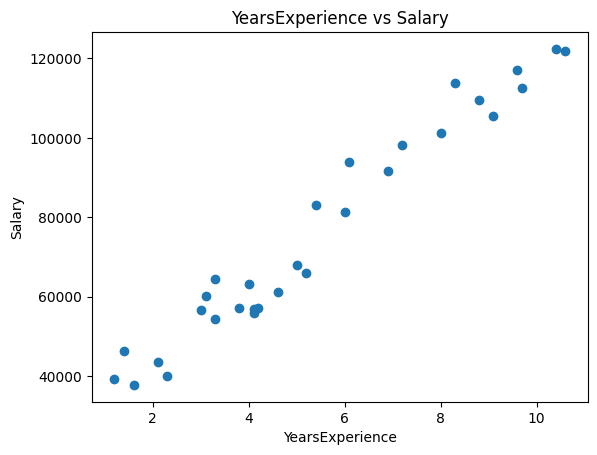

In [6]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('YearsExperience vs Salary')
plt.show()

In [7]:
# Dividing the dataset into independent and dependent variables
X= df[['YearsExperience']]
y = df[['Salary']]

In [8]:
X,y

(    YearsExperience
 0               1.2
 1               1.4
 2               1.6
 3               2.1
 4               2.3
 5               3.0
 6               3.1
 7               3.3
 8               3.3
 9               3.8
 10              4.0
 11              4.1
 12              4.1
 13              4.2
 14              4.6
 15              5.0
 16              5.2
 17              5.4
 18              6.0
 19              6.1
 20              6.9
 21              7.2
 22              8.0
 23              8.3
 24              8.8
 25              9.1
 26              9.6
 27              9.7
 28             10.4
 29             10.6,
       Salary
 0    39344.0
 1    46206.0
 2    37732.0
 3    43526.0
 4    39892.0
 5    56643.0
 6    60151.0
 7    54446.0
 8    64446.0
 9    57190.0
 10   63219.0
 11   55795.0
 12   56958.0
 13   57082.0
 14   61112.0
 15   67939.0
 16   66030.0
 17   83089.0
 18   81364.0
 19   93941.0
 20   91739.0
 21   98274.0
 22  101303.0
 23  113813.

In [9]:
# Training Test Split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 40)

In [10]:
X.shape

(30, 1)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((24, 1), (6, 1), (24, 1), (6, 1))

In [12]:
# Standardizing the dataset over independent train data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

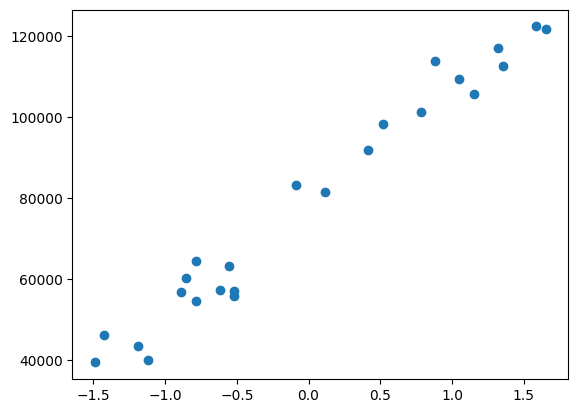

In [14]:
plt.scatter(X_train,y_train)
plt.show()

In [15]:
# Training the model Simple Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

LinearRegression()

In [16]:
model.fit(X_train,y_train)

LinearRegression()

In [17]:
print("The slope or coefficient of YearExperience is: ", model.coef_)
print("The intercept of the line is: ", model.intercept_)

The slope or coefficient of YearExperience is:  [[27728.61241643]]
The intercept of the line is:  [79011.83333333]


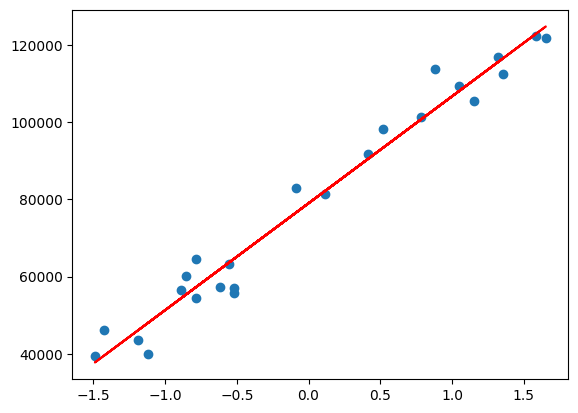

In [18]:
# Plotting the training data point (actual data)
plt.scatter(X_train, y_train)

# Plotting the regression line (predicted value)
plt.plot(X_train, model.predict(X_train),'r')
plt.show()

In Simple Terms

Blue dots (scatter plot): your real training data.

Red line: the line your model learned to predict outcomes.

In [19]:
y_pred_test = model.predict(X_test)

In [20]:
y_pred_test, y_test
y_pred_test = np.array(y_pred_test).flatten()
y_test = np.array(y_test).flatten()
data={
    "Predicted Data":y_pred_test,
    "Actual Data":y_test
    }
df = pd.DataFrame(data)
df.sample(5)

,Predicted Data,Actual Data
1,74802.316048,66030.0
0,41435.133167,37732.0
4,72948.583666,67939.0
2,83144.111769,93941.0
5,65533.654137,57082.0


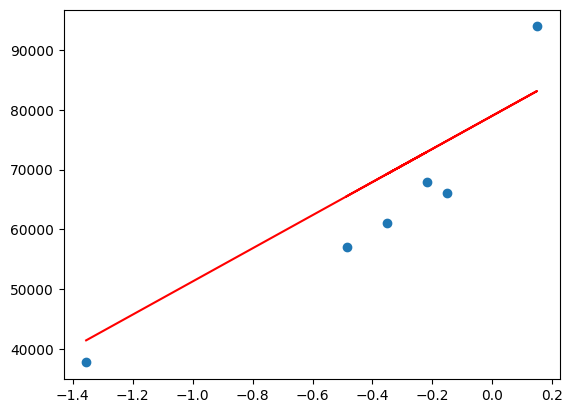

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model.predict(X_test), 'r')
plt.show()

Performance Metrics 
MSE, RMSE, MAE, R2 Score, Adjusted R2 Score

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [23]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  61641413.30887985
Mean Absolute Error:  7477.115691823841
Root Mean Squared Error:  7851.204576934666


In [24]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)
print(score)
print("R2 Score: ", score * 100, '%')

0.7775083459037232
R2 Score:  77.75083459037232 %


In [25]:
# Display Adjusted R2 Score
adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score: ", adjusted_r2 * 100, '%')

Adjusted R2 Score:  72.18854323796539 %


This means this model explain around 72.1% of the variation in the target variable after adjusting for the number of features.